# Flood Frequency Analysis of NVE Discharge Data

This notebook performs hydrological extreme value analysis including:
- Time series visualization
- Annual maximum extraction
- Seasonal pattern analysis
- Flood rose plot
- GEV distribution fitting (L-moments)
- Diagnostic plots
- Return level estimation


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genextreme
import lmoments3 as lm
import lmoments3.distr as lm_distr

plt.style.use('seaborn-v0_8-colorblind')

In [85]:
file_path = 'data/62.5.0-Vannføring-dogn-v1.csv'

df = pd.read_csv(file_path, sep=';', skiprows=1)
df.columns = ['time', 'discharge', 'corrected', 'quality']
df['time'] = pd.to_datetime(df['time'], utc=True)
df['discharge'] = (
    df['discharge']
    .str.replace(',', '.', regex=False)
    .astype(float)
)
df['discharge'] = pd.to_numeric(df['discharge'])
df = df.dropna(subset=['discharge'])
df = df.set_index('time')

df.head()


,discharge,corrected,quality
time,,,
1892-01-01 11:00:00+00:00,12.10079,0,3
1892-01-02 11:00:00+00:00,11.24779,0,3
1892-01-03 11:00:00+00:00,11.24779,0,3
1892-01-04 11:00:00+00:00,10.97214,0,3
1892-01-05 11:00:00+00:00,11.24779,0,3


## Time Series and Annual Maxima

In [86]:
annual_max = df['discharge'].resample('YE').max()
annual_max.head()

time
1892-12-31 00:00:00+00:00    356.5735
1893-12-31 00:00:00+00:00    304.5116
1894-12-31 00:00:00+00:00    258.9497
1895-12-31 00:00:00+00:00    228.6367
1896-12-31 00:00:00+00:00    339.8720
Freq: YE-DEC, Name: discharge, dtype: float64

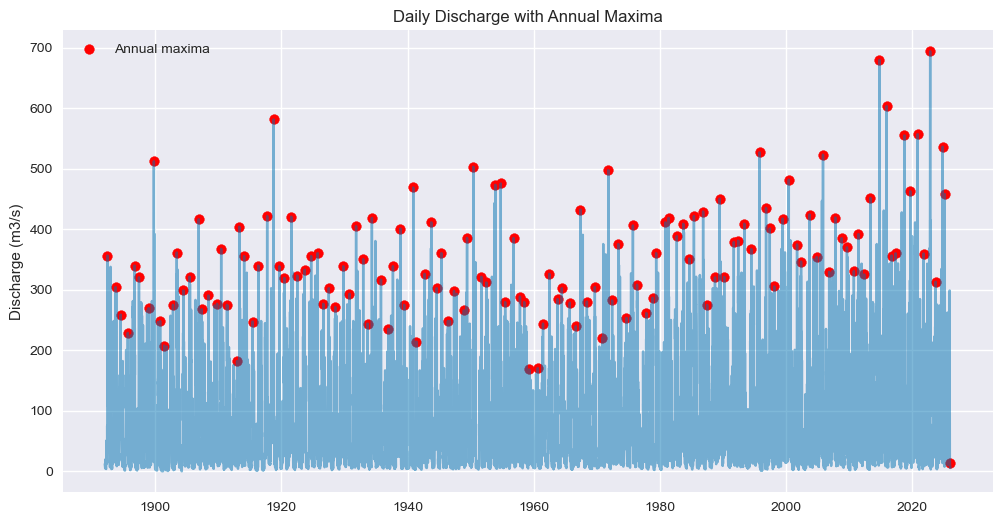

In [94]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['discharge'], alpha=0.5)
plt.scatter(df['discharge'].groupby(df.index.year).idxmax().values, annual_max.values,
            color='red', marker='o', label='Annual maxima')

plt.title('Daily Discharge with Annual Maxima')
plt.ylabel('Discharge (m3/s)')
plt.legend()
plt.show()

## Seasonality Analysis

In [5]:
monthly_mean = df['discharge'].groupby(df.index.month).mean()
monthly_mean.head()

time
1     24.379268
2     20.331614
3     20.361550
4     39.436203
5    124.376439
Name: discharge, dtype: float64

In [34]:
# Determine the midpoint of the DataFrame
midpoint = len(df) // 2

# Split the DataFrame into first half and second half
first_half = df.iloc[:midpoint]
second_half = df.iloc[midpoint:]

# Compute monthly mean for each half
monthly_mean_first = first_half['discharge'].groupby(first_half.index.month).mean()
monthly_mean_second = second_half['discharge'].groupby(second_half.index.month).mean()

# Show the first few values for each
print("First half monthly mean:")
print(monthly_mean_first.head())

print("\nSecond half monthly mean:")
print(monthly_mean_second.head())

First half monthly mean:
time
1     21.264915
2     18.738485
3     17.450715
4     34.560401
5    116.843999
Name: discharge, dtype: float64

Second half monthly mean:
time
1     27.493621
2     21.923901
3     23.272385
4     44.312005
5    131.908879
Name: discharge, dtype: float64


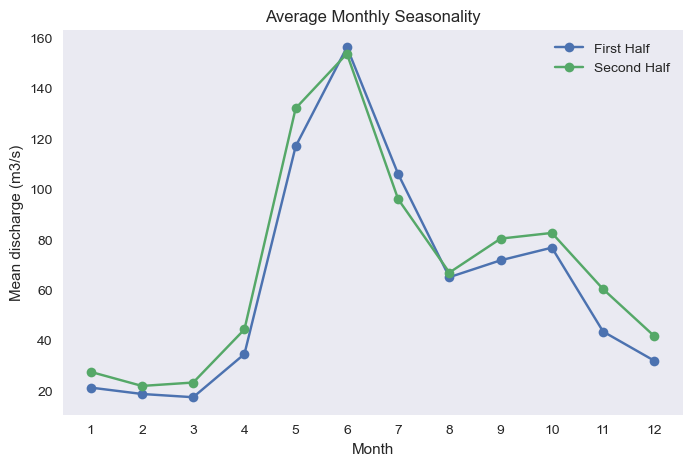

In [38]:
plt.figure(figsize=(8,5))
plt.plot(monthly_mean_first.index, monthly_mean_first.values, marker='o', label='First Half')
plt.plot(monthly_mean_second.index, monthly_mean_second.values, marker='o', label='Second Half')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Mean discharge (m3/s)')
plt.title('Average Monthly Seasonality')
plt.legend()
plt.grid()
plt.show()

## Flood Rose

In [76]:
df.head()
df['year'] = df.index.year
annual_max = df.groupby('year')['discharge'].idxmax()
max_values = df.loc[annual_max]
max_values.index.dayofyear

Index([155, 259, 190, 237, 263, 152, 347, 286, 283, 155,
       ...
       139, 288, 258, 324, 302, 316, 264, 306,  65,   1],
      dtype='int32', name='time', length=135)

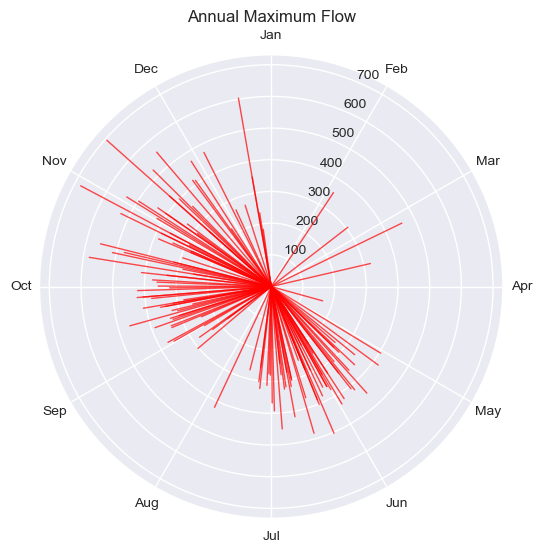

In [78]:
def flood_rose(df, qth=0.95):
    df = df.copy().sort_index()
    discharge = df['discharge']

    # --- Polar plot: annual maximum floods ---
    # Group by year and find the day of maximum discharge
    df['year'] = df.index.year
    annual_max = df.groupby('year')['discharge'].idxmax()  # index of max in each year
    max_values = df.loc[annual_max]

   
    theta = 2 * np.pi * (max_values.index.dayofyear / 365)
    r = max_values['discharge'].values

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    for t, radius in zip(theta, r):
        ax.plot([t, t], [0, radius], linewidth=1, color='red', alpha=0.7)

    # Month labels
    month_angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    ax.set_xticks(month_angles)
    ax.set_xticklabels(month_labels)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title('Annual Maximum Flow')

    plt.show()
    
flood_rose(df)

Mann-Kendall Trend Test for Annual Maximum Floods
Trend: increasing
Hypothesis: True (0=No trend, 1=Trend exists)
p-value: 5.028446581567536e-06
Slope: 0.8903769230769242
Intercept: 280.2167461538461


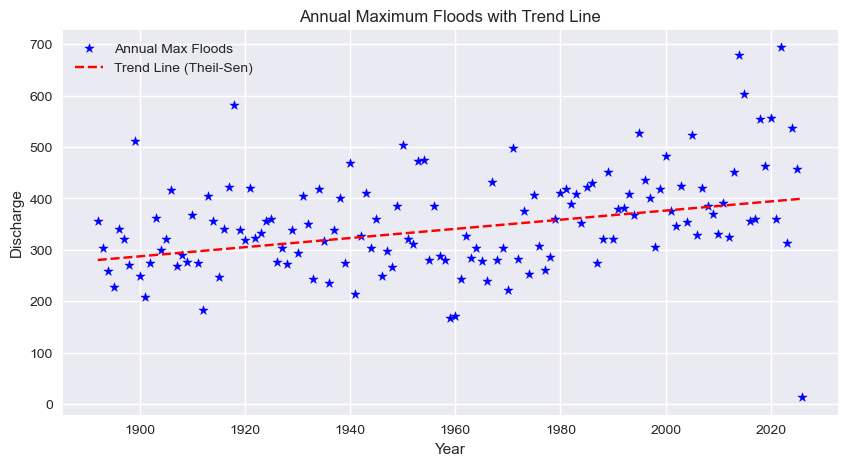

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

def ams_trend_test_with_plot(df):
    """
    Perform Mann-Kendall trend test on annual maximum floods and plot the results.

    Parameters:
    df : pd.DataFrame
        DataFrame with a datetime index and a 'discharge' column.

    Returns:
    result : object
        Mann-Kendall test result object.
    """
    df = df.copy().sort_index()
    
    # Extract annual maximum discharge
    df['year'] = df.index.year
    annual_max = df.groupby('year')['discharge'].max()
    
    # Mann-Kendall test
    result = mk.original_test(annual_max)
    
    # Print summary
    print("Mann-Kendall Trend Test for Annual Maximum Floods")
    print(f"Trend: {result.trend}")
    print(f"Hypothesis: {result.h} (0=No trend, 1=Trend exists)")
    print(f"p-value: {result.p}")
    print(f"Slope: {result.slope}")
    print(f"Intercept: {result.intercept}")
    
    # --- Plot ---
    plt.figure(figsize=(10,5))
    plt.scatter(annual_max.index, annual_max.values, marker='*', linestyle='-', label='Annual Max Floods', color='blue')
    
    # Trend line: Theil-Sen slope
    trend_line = result.intercept + result.slope * (annual_max.index - annual_max.index.min())
    plt.plot(annual_max.index, trend_line, color='red', linestyle='--', label='Trend Line (Theil-Sen)')
    
    plt.xlabel('Year')
    plt.ylabel('Discharge')
    plt.title('Annual Maximum Floods with Trend Line')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    return result

trend_result = ams_trend_test_with_plot(df)

Number of years: 135


/var/folders/bg/jx0ccdz945n94vz8vgs8fjhc0000gp/T/ipykernel_3308/2195495228.py:27: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  annual_max.plot(marker='o')


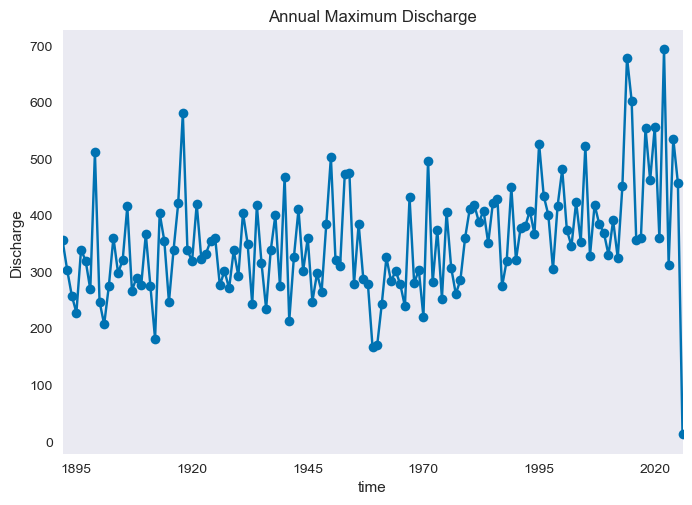

Initializing NUTS using adapt_diag...



L-moments parameters:
shape: -0.8597542677671919 loc: 2.1557807919708267 scale: 12.049175174263056


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, xi]


/opt/anaconda3/envs/floodfreq/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.



Bayesian parameters:
mu: 80.93133684032613 sigma: 89.55781209737971 xi: 0.4948833093819555


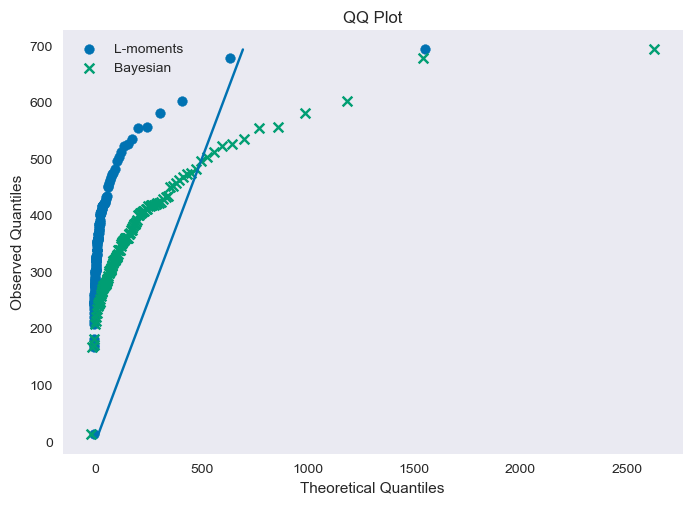

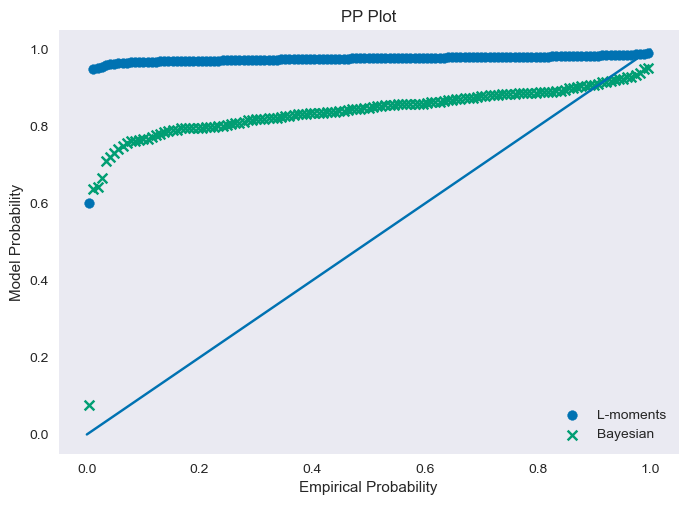

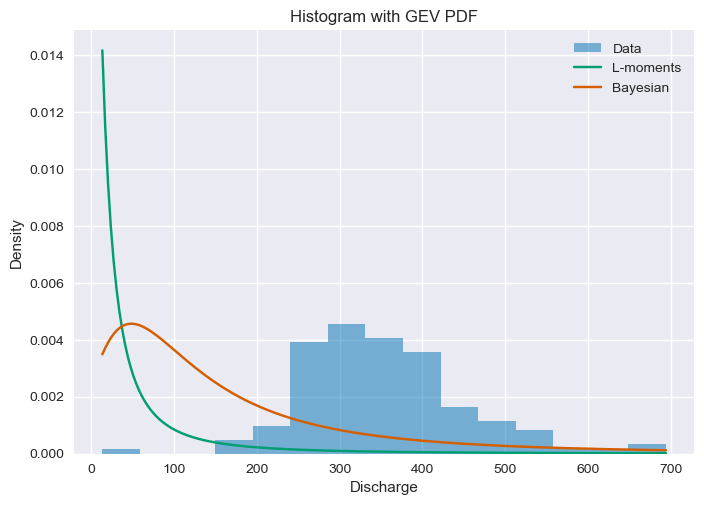

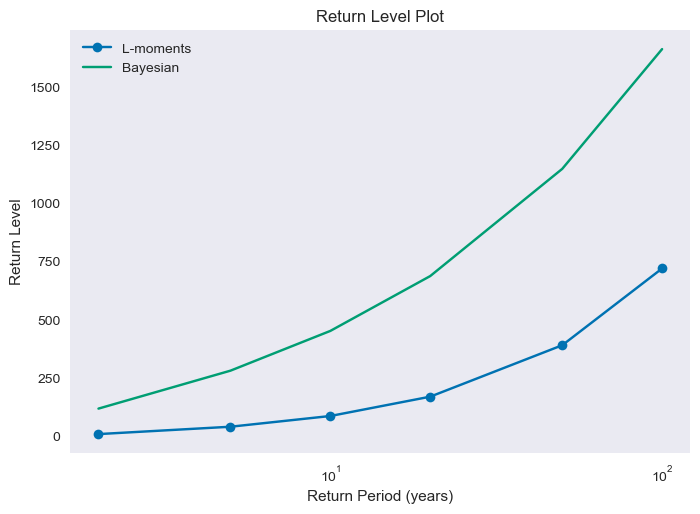


Design floods:

Return period 10 years:
L-moments: 85.1563190919094
Bayesian : 451.1027087010663

Return period 20 years:
L-moments: 168.28265457665134
Bayesian : 686.9555006519982

Return period 50 years:
L-moments: 389.48284868191604
Bayesian : 1147.994269317089

Return period 100 years:
L-moments: 719.6451912352492
Bayesian : 1663.109318788686


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

# ==============================
# 1. PREPARE DATA (AMS)
# ==============================
# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Annual maxima (calendar year)
annual_max = df['discharge'].resample('YE').max().dropna()

# Optional: hydrological year (uncomment if needed)
# annual_max = df['discharge'].resample('A-SEP').max().dropna()

print("Number of years:", len(annual_max))

# Convert to numpy
data = annual_max.values

# ==============================
# 2. BASIC VISUAL CHECK
# ==============================
plt.figure()
annual_max.plot(marker='o')
plt.title("Annual Maximum Discharge")
plt.ylabel("Discharge")
plt.grid()
plt.show()

# Sort data
data_sorted = np.sort(data)
n = len(data)

# Gringorten plotting position
p_emp = (np.arange(1, n+1) - 0.44) / (n + 0.12)

# ==============================
# 3. L-MOMENTS FIT
# ==============================
import lmoments3 as lm
from lmoments3 import distr

lmom = lm.lmom_ratios(data)
params_lmom = distr.gev.lmom_fit(lmom)

c_lmom = params_lmom['c']
loc_lmom = params_lmom['loc']
scale_lmom = params_lmom['scale']

gev_lmom = st.genextreme(c_lmom, loc=loc_lmom, scale=scale_lmom)

print("\nL-moments parameters:")
print("shape:", c_lmom, "loc:", loc_lmom, "scale:", scale_lmom)

# ==============================
# 4. BAYESIAN GEV (PyMC)
# ==============================
import pymc as pm
import pytensor.tensor as pt

# Use L-moments as initial values
mu_init = loc_lmom
sigma_init = scale_lmom
xi_init = -c_lmom   # convert to standard xi

with pm.Model() as model:

    mu = pm.Normal("mu", mu=mu_init, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)
    xi = pm.Normal("xi", mu=xi_init, sigma=0.2)

    def gev_logp(value):
        z = (value - mu) / sigma
        t = 1 + xi * z

        # enforce constraint
        valid = t > 0

        logp = (
            -pt.log(sigma)
            - (1/xi + 1) * pt.log(t)
            - t ** (-1/xi)
        )

        return pt.sum(pt.switch(valid, logp, -np.inf))

    pm.Potential("likelihood", gev_logp(data))

    trace = pm.sample(
        2000,
        tune=1000,
        target_accept=0.95,
        init="adapt_diag"
    )

# Posterior means
mu_b = trace.posterior["mu"].mean().values
sigma_b = trace.posterior["sigma"].mean().values
xi_b = trace.posterior["xi"].mean().values

print("\nBayesian parameters:")
print("mu:", mu_b, "sigma:", sigma_b, "xi:", xi_b)

# scipy uses opposite sign convention
gev_bayes = st.genextreme(-xi_b, loc=mu_b, scale=sigma_b)

# ==============================
# 5. QQ PLOT
# ==============================
q_lmom = gev_lmom.ppf(p_emp)
q_bayes = gev_bayes.ppf(p_emp)

plt.figure()
plt.scatter(q_lmom, data_sorted, label="L-moments")
plt.scatter(q_bayes, data_sorted, label="Bayesian", marker='x')
plt.plot(data_sorted, data_sorted)
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Quantiles")
plt.title("QQ Plot")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 6. PP PLOT
# ==============================
p_lmom = gev_lmom.cdf(data_sorted)
p_bayes = gev_bayes.cdf(data_sorted)

plt.figure()
plt.scatter(p_emp, p_lmom, label="L-moments")
plt.scatter(p_emp, p_bayes, label="Bayesian", marker='x')
plt.plot([0,1], [0,1])
plt.xlabel("Empirical Probability")
plt.ylabel("Model Probability")
plt.title("PP Plot")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 7. HISTOGRAM + PDF
# ==============================
x = np.linspace(min(data), max(data), 200)

plt.figure()
plt.hist(data, bins=15, density=True, alpha=0.5, label="Data")
plt.plot(x, gev_lmom.pdf(x), label="L-moments")
plt.plot(x, gev_bayes.pdf(x), label="Bayesian")
plt.xlabel("Discharge")
plt.ylabel("Density")
plt.title("Histogram with GEV PDF")
plt.legend()
plt.show()

# ==============================
# 8. RETURN LEVEL PLOT
# ==============================
T = np.array([2, 5, 10, 20, 50, 100])
prob = 1 - 1/T

z_lmom = gev_lmom.ppf(prob)
z_bayes = gev_bayes.ppf(prob)

plt.figure()
plt.semilogx(T, z_lmom, marker='o', label="L-moments")
plt.semilogx(T, z_bayes, marker='x', label="Bayesian")
plt.xlabel("Return Period (years)")
plt.ylabel("Return Level")
plt.title("Return Level Plot")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 9. DESIGN FLOODS
# ==============================
def design_flood(T, dist):
    return dist.ppf(1 - 1/T)

print("\nDesign floods:")
for T in [10, 20, 50, 100]:
    print(f"\nReturn period {T} years:")
    print("L-moments:", design_flood(T, gev_lmom))
    print("Bayesian :", design_flood(T, gev_bayes))

## Fit GEV Distribution (L-moments)

## Diagnostic Plots

## Return Level Plot

## Design Floods